<a href="https://colab.research.google.com/github/MBekic/Klasifikacija-tipova-tkiva-kori-tenjem-ResNet-i-EfficientNet-arhitektura/blob/main/Analiza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import time
import copy
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from google.colab import files, drive
import zipfile

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Uređaj:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Uređaj: cuda
GPU: Tesla T4


In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = "/content/drive/MyDrive/MHIST"
print(os.listdir(base_path))

['annotations.csv', 'images']


In [ ]:
import pandas as pd

base_path = "/content/drive/MyDrive/MHIST"
csv_path = os.path.join(base_path, "annotations.csv")

df = pd.read_csv(csv_path)
print(df.head())
print(df.columns)
print(df.shape)

      Image Name Majority Vote Label  \
0  MHIST_aaa.png                 SSA   
1  MHIST_aab.png                  HP   
2  MHIST_aac.png                 SSA   
3  MHIST_aae.png                  HP   
4  MHIST_aaf.png                 SSA   

   Number of Annotators who Selected SSA (Out of 7) Partition  
0                                                 6     train  
1                                                 0     train  
2                                                 5     train  
3                                                 1     train  
4                                                 5     train  
Index(['Image Name', 'Majority Vote Label',
       'Number of Annotators who Selected SSA (Out of 7)', 'Partition'],
      dtype='object')
(3152, 4)


In [ ]:
print(df["Majority Vote Label"].value_counts())
print()
print(df["Partition"].value_counts())

Majority Vote Label
HP     2162
SSA     990
Name: count, dtype: int64

Partition
train    2175
test      977
Name: count, dtype: int64


In [ ]:
images_path = os.path.join(base_path, "images")

df["image_path"] = df["Image Name"].apply(lambda x: os.path.join(images_path, x))
df["label"] = df["Majority Vote Label"].map({"HP": 0, "SSA": 1})

print(df[["Image Name", "image_path", "Majority Vote Label", "label", "Partition"]].head())

      Image Name                                         image_path  \
0  MHIST_aaa.png  /content/drive/MyDrive/MHIST/images/MHIST_aaa.png   
1  MHIST_aab.png  /content/drive/MyDrive/MHIST/images/MHIST_aab.png   
2  MHIST_aac.png  /content/drive/MyDrive/MHIST/images/MHIST_aac.png   
3  MHIST_aae.png  /content/drive/MyDrive/MHIST/images/MHIST_aae.png   
4  MHIST_aaf.png  /content/drive/MyDrive/MHIST/images/MHIST_aaf.png   

  Majority Vote Label  label Partition  
0                 SSA      1     train  
1                  HP      0     train  
2                 SSA      1     train  
3                  HP      0     train  
4                 SSA      1     train  


In [ ]:
train_df = df[df["Partition"] == "train"].copy()
test_df = df[df["Partition"] == "test"].copy()

In [ ]:
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 1740
Val: 435
Test: 977


In [ ]:
print(train_df.iloc[0]["image_path"])
print(os.path.exists(train_df.iloc[0]["image_path"]))

/content/drive/MyDrive/MHIST/images/MHIST_edl.png
True


In [ ]:
print(test_df.iloc[0]["image_path"])
print(os.path.exists(test_df.iloc[0]["image_path"]))

/content/drive/MyDrive/MHIST/images/MHIST_aag.png
True


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
from torch.utils.data import Dataset
from PIL import Image

class MHISTDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_path = self.dataframe.loc[idx, "image_path"]
        label = self.dataframe.loc[idx, "label"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
train_dataset = MHISTDataset(train_df, transform=train_transform)
val_dataset = MHISTDataset(val_df, transform=val_test_transform)
test_dataset = MHISTDataset(test_df, transform=val_test_transform)

print("Train dataset:", len(train_dataset))
print("Val dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 1740
Val dataset: 435
Test dataset: 977


In [ ]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 55
Val batches: 14
Test batches: 31


In [ ]:
images, labels = next(iter(train_loader))

print("Shape slika:", images.shape)
print("Shape labela:", labels.shape)
print("Primjeri labela:", labels[:10])

Shape slika: torch.Size([32, 3, 224, 224])
Shape labela: torch.Size([32])
Primjeri labela: tensor([1, 0, 1, 0, 0, 0, 0, 0, 1, 0])


In [ ]:
resnet_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_features, 2)

resnet_model = resnet_model.to(device)

print(resnet_model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 193MB/s]


Linear(in_features=512, out_features=2, bias=True)


In [ ]:
criterion = nn.CrossEntropyLoss()

resnet_optimizer = optim.Adam(resnet_model.parameters(), lr=1e-4)

num_epochs = 10

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, epoch_f1

In [ ]:
def evaluate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, epoch_f1

In [ ]:
best_resnet_weights = copy.deepcopy(resnet_model.state_dict())
best_val_f1 = 0.0

resnet_history = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": []
}

start_time = time.time()

for epoch in range(num_epochs):
    train_loss, train_acc, train_f1 = train_one_epoch(
        resnet_model, train_loader, criterion, resnet_optimizer, device
    )

    val_loss, val_acc, val_f1 = evaluate(
        resnet_model, val_loader, criterion, device
    )

    resnet_history["train_loss"].append(train_loss)
    resnet_history["train_acc"].append(train_acc)
    resnet_history["train_f1"].append(train_f1)
    resnet_history["val_loss"].append(val_loss)
    resnet_history["val_acc"].append(val_acc)
    resnet_history["val_f1"].append(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_resnet_weights = copy.deepcopy(resnet_model.state_dict())

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val   F1: {val_f1:.4f}")
    print("-" * 60)

resnet_training_time = time.time() - start_time

resnet_model.load_state_dict(best_resnet_weights)

print(f"Najbolji Val F1: {best_val_f1:.4f}")
print(f"Vrijeme treniranja: {resnet_training_time:.2f} sekundi")

Epoch [1/10]
Train Loss: 0.4363 | Train Acc: 0.7937 | Train F1: 0.6233
Val   Loss: 0.4020 | Val   Acc: 0.8115 | Val   F1: 0.5543
------------------------------------------------------------
Epoch [2/10]
Train Loss: 0.2751 | Train Acc: 0.8764 | Train F1: 0.7790
Val   Loss: 0.3705 | Val   Acc: 0.8506 | Val   F1: 0.7751
------------------------------------------------------------
Epoch [3/10]
Train Loss: 0.2154 | Train Acc: 0.9161 | Train F1: 0.8510
Val   Loss: 0.2885 | Val   Acc: 0.8713 | Val   F1: 0.7705
------------------------------------------------------------
Epoch [4/10]
Train Loss: 0.1537 | Train Acc: 0.9437 | Train F1: 0.9008
Val   Loss: 0.3387 | Val   Acc: 0.8506 | Val   F1: 0.7636
------------------------------------------------------------
Epoch [5/10]
Train Loss: 0.1281 | Train Acc: 0.9517 | Train F1: 0.9153
Val   Loss: 0.3142 | Val   Acc: 0.8736 | Val   F1: 0.7773
------------------------------------------------------------
Epoch [6/10]
Train Loss: 0.1076 | Train Acc: 0.959

In [ ]:
resnet_test_loss, resnet_test_acc, resnet_test_f1 = evaluate(
    resnet_model, test_loader, criterion, device
)

print(f"ResNet Test Loss: {resnet_test_loss:.4f}")
print(f"ResNet Test Accuracy: {resnet_test_acc:.4f}")
print(f"ResNet Test F1-score: {resnet_test_f1:.4f}")

ResNet Test Loss: 0.5505
ResNet Test Accuracy: 0.8219
ResNet Test F1-score: 0.7456


In [ ]:
def get_predictions(model, dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return all_labels, all_preds

In [ ]:
resnet_y_true, resnet_y_pred = get_predictions(resnet_model, test_loader, device)

print("Classification Report:")
print(classification_report(resnet_y_true, resnet_y_pred, target_names=["HP", "SSA"]))

print("Confusion Matrix:")
print(confusion_matrix(resnet_y_true, resnet_y_pred))

Classification Report:
              precision    recall  f1-score   support

          HP       0.84      0.89      0.86       617
         SSA       0.79      0.71      0.75       360

    accuracy                           0.82       977
   macro avg       0.81      0.80      0.80       977
weighted avg       0.82      0.82      0.82       977

Confusion Matrix:
[[548  69]
 [105 255]]


In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

resnet_params = count_parameters(resnet_model)
print(f"Broj trenirajućih parametara (ResNet18): {resnet_params:,}")

Broj trenirajućih parametara (ResNet18): 11,177,538


In [ ]:
if torch.cuda.is_available():
    print(f"Max GPU memory allocated: {torch.cuda.max_memory_allocated() / 1024**2:.2f} MB")
    print(f"Max GPU memory reserved: {torch.cuda.max_memory_reserved() / 1024**2:.2f} MB")

Max GPU memory allocated: 942.88 MB
Max GPU memory reserved: 1240.00 MB


In [ ]:
efficientnet_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

num_features = efficientnet_model.classifier[1].in_features
efficientnet_model.classifier[1] = nn.Linear(num_features, 2)

efficientnet_model = efficientnet_model.to(device)

print(efficientnet_model.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 69.3MB/s]


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


In [ ]:
efficientnet_optimizer = optim.Adam(efficientnet_model.parameters(), lr=1e-4)

In [ ]:
best_efficientnet_weights = copy.deepcopy(efficientnet_model.state_dict())
best_val_f1_eff = 0.0

efficientnet_history = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": []
}

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

start_time = time.time()

for epoch in range(num_epochs):
    train_loss, train_acc, train_f1 = train_one_epoch(
        efficientnet_model, train_loader, criterion, efficientnet_optimizer, device
    )

    val_loss, val_acc, val_f1 = evaluate(
        efficientnet_model, val_loader, criterion, device
    )

    efficientnet_history["train_loss"].append(train_loss)
    efficientnet_history["train_acc"].append(train_acc)
    efficientnet_history["train_f1"].append(train_f1)
    efficientnet_history["val_loss"].append(val_loss)
    efficientnet_history["val_acc"].append(val_acc)
    efficientnet_history["val_f1"].append(val_f1)

    if val_f1 > best_val_f1_eff:
        best_val_f1_eff = val_f1
        best_efficientnet_weights = copy.deepcopy(efficientnet_model.state_dict())

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val   F1: {val_f1:.4f}")
    print("-" * 60)

efficientnet_training_time = time.time() - start_time

efficientnet_model.load_state_dict(best_efficientnet_weights)

print(f"Najbolji Val F1 (EfficientNet): {best_val_f1_eff:.4f}")
print(f"Vrijeme treniranja (EfficientNet): {efficientnet_training_time:.2f} sekundi")

Epoch [1/10]
Train Loss: 0.5128 | Train Acc: 0.7603 | Train F1: 0.5741
Val   Loss: 0.3427 | Val   Acc: 0.8437 | Val   F1: 0.7280
------------------------------------------------------------
Epoch [2/10]
Train Loss: 0.3431 | Train Acc: 0.8483 | Train F1: 0.7381
Val   Loss: 0.2944 | Val   Acc: 0.8759 | Val   F1: 0.7769
------------------------------------------------------------
Epoch [3/10]
Train Loss: 0.2832 | Train Acc: 0.8764 | Train F1: 0.7861
Val   Loss: 0.2744 | Val   Acc: 0.8805 | Val   F1: 0.7886
------------------------------------------------------------
Epoch [4/10]
Train Loss: 0.2269 | Train Acc: 0.9132 | Train F1: 0.8454
Val   Loss: 0.2765 | Val   Acc: 0.8920 | Val   F1: 0.7983
------------------------------------------------------------
Epoch [5/10]
Train Loss: 0.1549 | Train Acc: 0.9414 | Train F1: 0.8984
Val   Loss: 0.2814 | Val   Acc: 0.8851 | Val   F1: 0.8000
------------------------------------------------------------
Epoch [6/10]
Train Loss: 0.1370 | Train Acc: 0.942

In [ ]:
efficientnet_test_loss, efficientnet_test_acc, efficientnet_test_f1 = evaluate(
    efficientnet_model, test_loader, criterion, device
)

print(f"EfficientNet Test Loss: {efficientnet_test_loss:.4f}")
print(f"EfficientNet Test Accuracy: {efficientnet_test_acc:.4f}")
print(f"EfficientNet Test F1-score: {efficientnet_test_f1:.4f}")

EfficientNet Test Loss: 0.4247
EfficientNet Test Accuracy: 0.8393
EfficientNet Test F1-score: 0.7721


In [ ]:
efficientnet_y_true, efficientnet_y_pred = get_predictions(efficientnet_model, test_loader, device)

print("Classification Report:")
print(classification_report(efficientnet_y_true, efficientnet_y_pred, target_names=["HP", "SSA"]))

print("Confusion Matrix:")
print(confusion_matrix(efficientnet_y_true, efficientnet_y_pred))

Classification Report:
              precision    recall  f1-score   support

          HP       0.85      0.90      0.88       617
         SSA       0.81      0.74      0.77       360

    accuracy                           0.84       977
   macro avg       0.83      0.82      0.82       977
weighted avg       0.84      0.84      0.84       977

Confusion Matrix:
[[554  63]
 [ 94 266]]


In [ ]:
efficientnet_params = count_parameters(efficientnet_model)
print(f"Broj trenirajućih parametara (EfficientNet-B0): {efficientnet_params:,}")

if torch.cuda.is_available():
    print(f"Max GPU memory allocated: {torch.cuda.max_memory_allocated() / 1024**2:.2f} MB")
    print(f"Max GPU memory reserved: {torch.cuda.max_memory_reserved() / 1024**2:.2f} MB")

Broj trenirajućih parametara (EfficientNet-B0): 4,010,110
Max GPU memory allocated: 3058.80 MB
Max GPU memory reserved: 3450.00 MB


In [ ]:
results_df = pd.DataFrame({
    "Model": ["ResNet18", "EfficientNet-B0"],
    "Test Accuracy": [resnet_test_acc, efficientnet_test_acc],
    "Test F1-score": [resnet_test_f1, efficientnet_test_f1],
    "Training Time (s)": [resnet_training_time, efficientnet_training_time],
    "Trainable Parameters": [resnet_params, efficientnet_params],
    "GPU Memory Allocated (MB)": [942.88, 3058.80],
    "GPU Memory Reserved (MB)": [1240.00, 3450.00]
})

results_df

,Model,Test Accuracy,Test F1-score,Training Time (s),Trainable Parameters,GPU Memory Allocated (MB),GPU Memory Reserved (MB)
0,ResNet18,0.821904,0.745614,537.829041,11177538,942.88,1240.0
1,EfficientNet-B0,0.839304,0.772134,156.216298,4010110,3058.80,3450.0


In [ ]:
results_df_rounded = results_df.copy()
results_df_rounded["Test Accuracy"] = results_df_rounded["Test Accuracy"].round(4)
results_df_rounded["Test F1-score"] = results_df_rounded["Test F1-score"].round(4)
results_df_rounded["Training Time (s)"] = results_df_rounded["Training Time (s)"].round(2)
results_df_rounded

,Model,Test Accuracy,Test F1-score,Training Time (s),Trainable Parameters,GPU Memory Allocated (MB),GPU Memory Reserved (MB)
0,ResNet18,0.8219,0.7456,537.83,11177538,942.88,1240.0
1,EfficientNet-B0,0.8393,0.7721,156.22,4010110,3058.80,3450.0


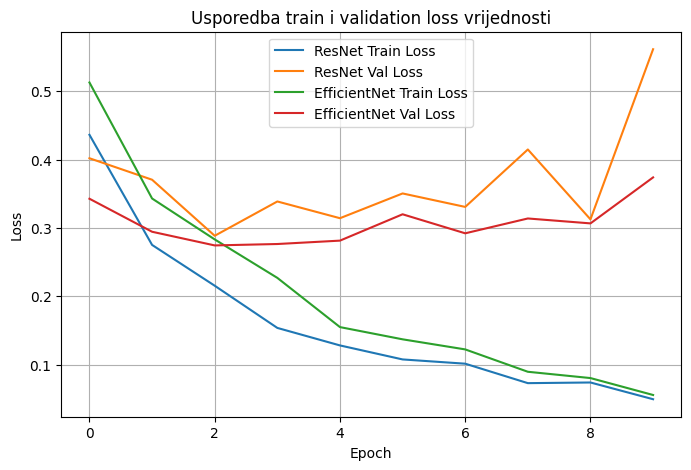

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(resnet_history["train_loss"], label="ResNet Train Loss")
plt.plot(resnet_history["val_loss"], label="ResNet Val Loss")
plt.plot(efficientnet_history["train_loss"], label="EfficientNet Train Loss")
plt.plot(efficientnet_history["val_loss"], label="EfficientNet Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Usporedba train i validation loss vrijednosti")
plt.legend()
plt.grid(True)
plt.show()

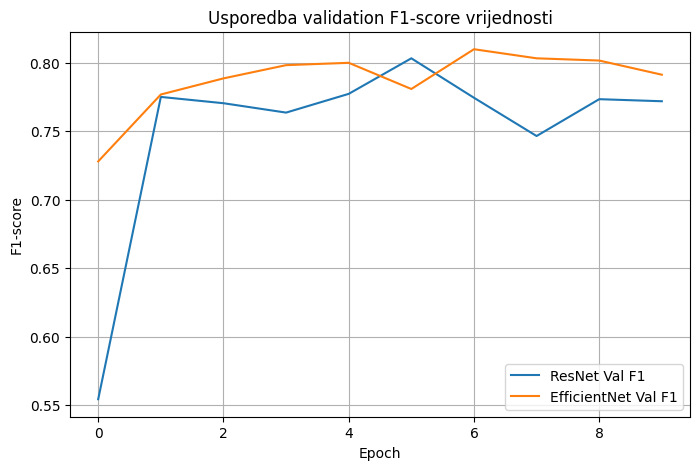

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(resnet_history["val_f1"], label="ResNet Val F1")
plt.plot(efficientnet_history["val_f1"], label="EfficientNet Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title("Usporedba validation F1-score vrijednosti")
plt.legend()
plt.grid(True)
plt.show()